In [2]:
import cosmosis
import numpy as np
from timeit import default_timer
import matplotlib.pyplot as plt
import sacc
import os

In [3]:
# make matplotlib ticks go inwards
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# minor tick size 5, major size 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10

In [4]:
help(exec)

Help on built-in function exec in module builtins:

exec(source, globals=None, locals=None, /, *, closure=None)
    Execute the given source in the context of globals and locals.
    
    The source may be a string representing one or more Python statements
    or a code object as returned by compile().
    The globals must be a dictionary and locals can be any mapping,
    defaulting to the current globals and locals.
    If only globals is given, locals defaults to it.
    The closure must be a tuple of cellvars, and can only be used
    when source is a code object requiring exactly that many cellvars.



In [5]:

def block_from_directory(directory):
    """Load a Cosmosis DataBlock from the output files in a directory."""
    block = cosmosis.DataBlock()
    for section in os.listdir(directory):
        for filename in os.listdir(os.path.join(directory, section)):
            if filename == "values.txt":
                with open(os.path.join(directory, section, filename), 'r') as f:
                    for lin in f:
                        key, value = lin.rsplit("=", 1)
                        value = eval(value)
                        block[section, key.strip()] = value
            else:
                try:
                    data = np.loadtxt(os.path.join(directory, section, filename))
                except ValueError:
                    with open(os.path.join(directory, section, filename), 'r') as f:
                        lines = f.readlines()
                    data = [line.strip() for line in lines if not line.startswith('#') and line.strip()]
                    
                key = filename.replace('.txt', '')
                block[section, key] = data

    return block

block = block_from_directory("output/euclid-rr2-fourier")

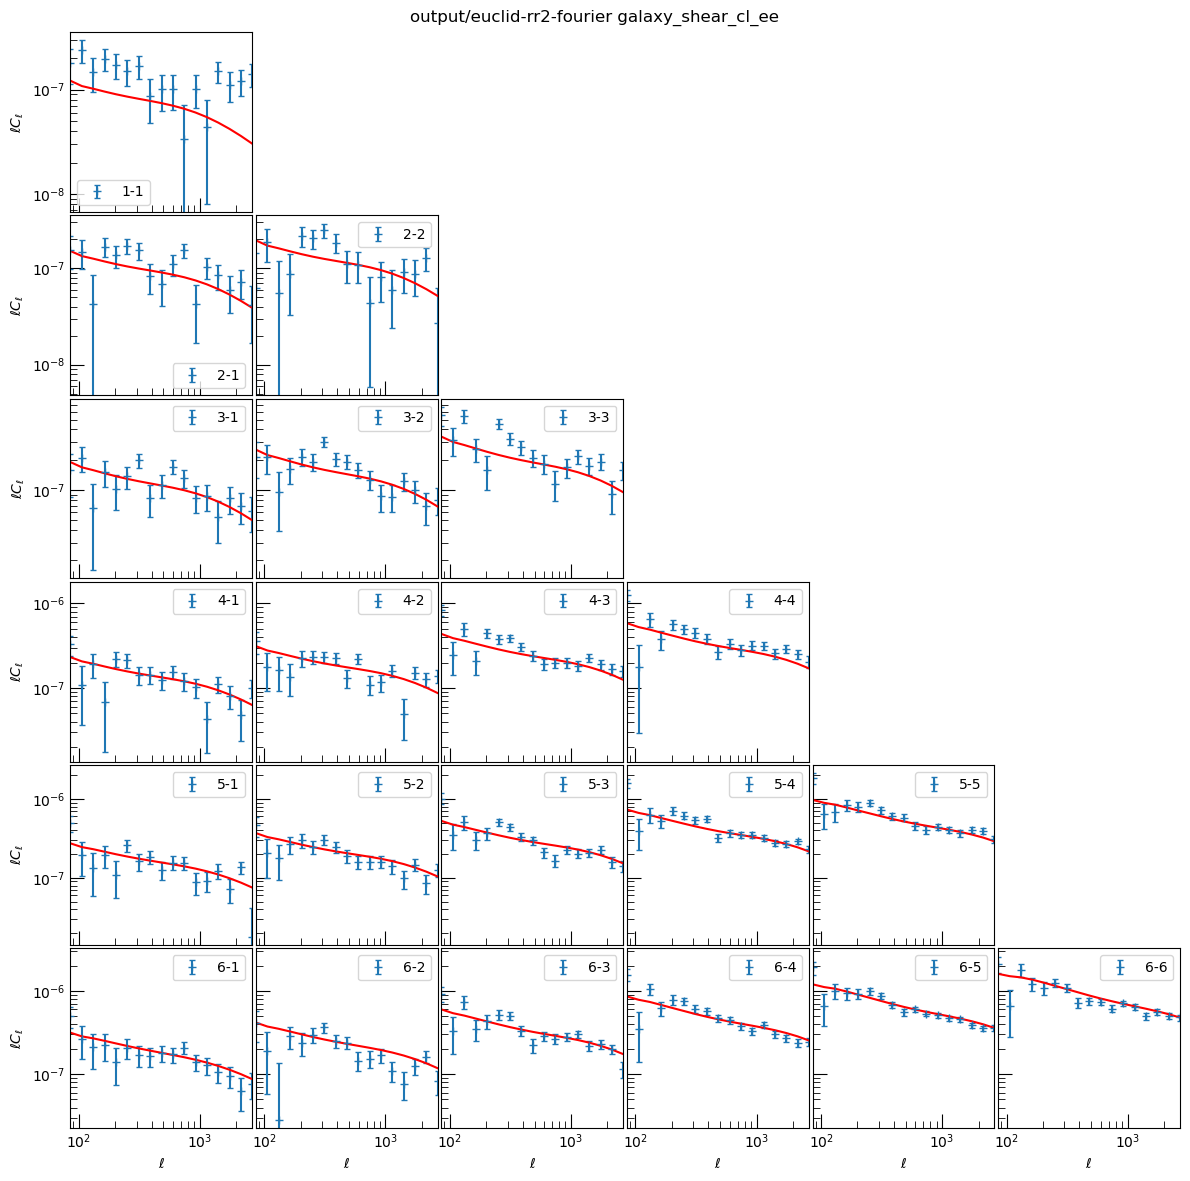

In [38]:
def plot_2pt(dirname, is_real=False):
    block = block_from_directory(dirname)
    data = block["data_vector", "2pt_like_data"]
    theory = block["data_vector", "2pt_like_theory"]
    data_type = block["data_vector", "2pt_like_name"]
    cov = block["data_vector", "2pt_like_covariance"]
    data_types = np.unique(data_type)
    for dt in data_types:
        angle = block["data_vector", f"{dt}_angle"]
        bin1 = block["data_vector", f"{dt}_bin1"]
        bin2 = block["data_vector", f"{dt}_bin2"]
        bins = set(bin1)
        nbin = len(bins)

        fig, axes = plt.subplots(nbin, nbin, figsize=(2*nbin, 2*nbin), sharex='col', sharey='row')
        fig.suptitle(dirname + " " + dt)
        mask = data_type == dt
        data_dt = data[mask]
        theory_dt = theory[mask]
        cov_dt = cov[mask][:, mask]
        for i in range(nbin):
            for j in range(nbin):
                submask = (bin1 == i) & (bin2 == j)

                # Remove upper triangle
                if submask.sum() == 0:
                    fig.delaxes(axes[i, j])
                    continue

                # Plot data
                x = angle[submask]

                if is_real:
                    x = np.degrees(x) * 60
                y = data_dt[submask]
                sigma = x * np.sqrt(np.diag(cov_dt[submask][:, submask]))
                axes[i, j].errorbar(x, x * y, yerr=sigma, fmt='+', capsize=2, label=f'{i+1}-{j+1}')

                # Plot theory
                axes[i, j].plot(x, x * theory_dt[submask], 'r-')

                # Setup axes
                axes[i, j].legend()
                axes[i, j].set_xscale('log')
                axes[i, j].set_yscale('log')
                xmin, xmax = axes[i, j].get_xlim()
                xmin = max(xmin, x.min())
                xmax = min(xmax, x.max())
                axes[i, j].set_xlim(xmin, xmax)

                if is_real and j == 0:
                    axes[i, j].set_ylabel(r'$\theta \xi(\theta)$')
                elif (not is_real) and j == 0:
                    axes[i, j].set_ylabel(r'$\ell C_\ell$')
                
                if is_real and i == nbin - 1:
                    axes[i, j].set_xlabel(r'$\theta$ [arcmin]')
                elif (not is_real) and i == nbin - 1:
                    axes[i, j].set_xlabel(r'$\ell$')

        
        fig.tight_layout()
        fig.subplots_adjust(hspace=0.02, wspace=0.02)

plot_2pt("output/euclid-rr2-fourier")
plt.savefig("v2.png")
# plot_2pt("output/euclid-rr2-fourier-map")
# plot_2pt("output/euclid-rr2-real", is_real=True)